# Chương 3 — Phân tích khám phá dữ liệu (EDA)

**Thành viên 1 — Data Engineer**  
**Dữ liệu:** VCB, FPT, HPG, VIC, VNM — 2015 → 2026 (nguồn: vnstock/VCI, fallback yfinance)

## Nội dung
1. Tổng quan dữ liệu (shape, date range, missing values)
2. Biểu đồ giá đóng cửa theo thời gian
3. Phân tích lợi suất hàng ngày (daily returns)
4. Ma trận tương quan giữa các mã
5. Kiểm định tính dừng — ADF Test
6. Phân rã chuỗi thời gian (Trend / Seasonal / Residual)
7. Trực quan hoá chỉ số kỹ thuật
8. **Điều tra outlier — Trường hợp VIC**
9. Phân chia Train / Test (single split + walk-forward 5-fold)
10. **Liên kết EDA → kỳ vọng mô hình** (bridge sang Chương 4–5)
11. Bảng tóm tắt cho báo cáo


---
## 0 — Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#2563EB', '#DC2626', '#16A34A', '#D97706', '#7C3AED']

In [2]:
ROOT         = Path('..').resolve()
RAW_DIR      = ROOT / 'data' / 'raw'
FEATURED_DIR = ROOT / 'data' / 'processed' / 'featured'
SPLITS_DIR   = ROOT / 'data' / 'processed' / 'splits'
PLOTS_DIR    = ROOT / 'results' / 'eda' / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

TICKERS = ['VCB', 'FPT', 'HPG', 'VIC', 'VNM']
COLORS  = dict(zip(TICKERS, PALETTE))

# Load tất cả dữ liệu raw và featured
raw      = {t: pd.read_csv(RAW_DIR / f'{t}.csv', parse_dates=['date']) for t in TICKERS}
featured = {t: pd.read_csv(FEATURED_DIR / f'{t}_featured.csv', parse_dates=['date']) for t in TICKERS}
split_info = json.loads((SPLITS_DIR / 'split_info.json').read_text())

print('Dữ liệu đã load xong.')

Dữ liệu đã load xong.


---
## 1 — Tổng quan dữ liệu

In [3]:
rows = []
for t in TICKERS:
    df = raw[t].sort_values('date')
    rows.append({
        'Mã':           t,
        'Từ ngày':      str(df['date'].min().date()),
        'Đến ngày':     str(df['date'].max().date()),
        'Số phiên':     len(df),
        'Thiếu (close)': int(df['close'].isna().sum()),
        'Giá min':      round(df['close'].min(), 2),
        'Giá max':      round(df['close'].max(), 2),
        'Giá TB':       round(df['close'].mean(), 2),
    })

overview_df = pd.DataFrame(rows)
print(overview_df.to_string(index=False))

 Mã    Từ ngày   Đến ngày  Số phiên  Thiếu (close)  Giá min  Giá max  Giá TB
VCB 2015-07-16 2026-05-08      2702              0    11.59    76.00   38.33
FPT 2015-07-16 2026-05-08      2702              0     7.69   131.67   42.62
HPG 2015-07-16 2026-05-08      2702              0     2.47    33.25   14.78
VIC 2015-07-16 2026-05-08      2702              0    10.80   226.00   39.21
VNM 2015-07-16 2026-05-08      2702              0    34.46   102.22   65.98


In [4]:
# Thống kê mô tả cho close price
desc = pd.DataFrame({t: raw[t]['close'].describe() for t in TICKERS}).round(2)
print('Thống kê mô tả — Giá đóng cửa:')
print(desc.to_string())

Thống kê mô tả — Giá đóng cửa:
           VCB      FPT      HPG      VIC      VNM
count  2702.00  2702.00  2702.00  2702.00  2702.00
mean     38.33    42.62    14.78    39.21    65.98
std      17.14    35.13     8.51    29.74    11.67
min      11.59     7.69     2.47    10.80    34.46
25%      23.54    13.58     7.54    20.60    58.88
50%      39.32    24.08    12.84    34.80    64.68
75%      56.23    61.78    22.11    47.50    72.34
max      76.00   131.67    33.25   226.00   102.22


---
## 2 — Biểu đồ giá đóng cửa theo thời gian

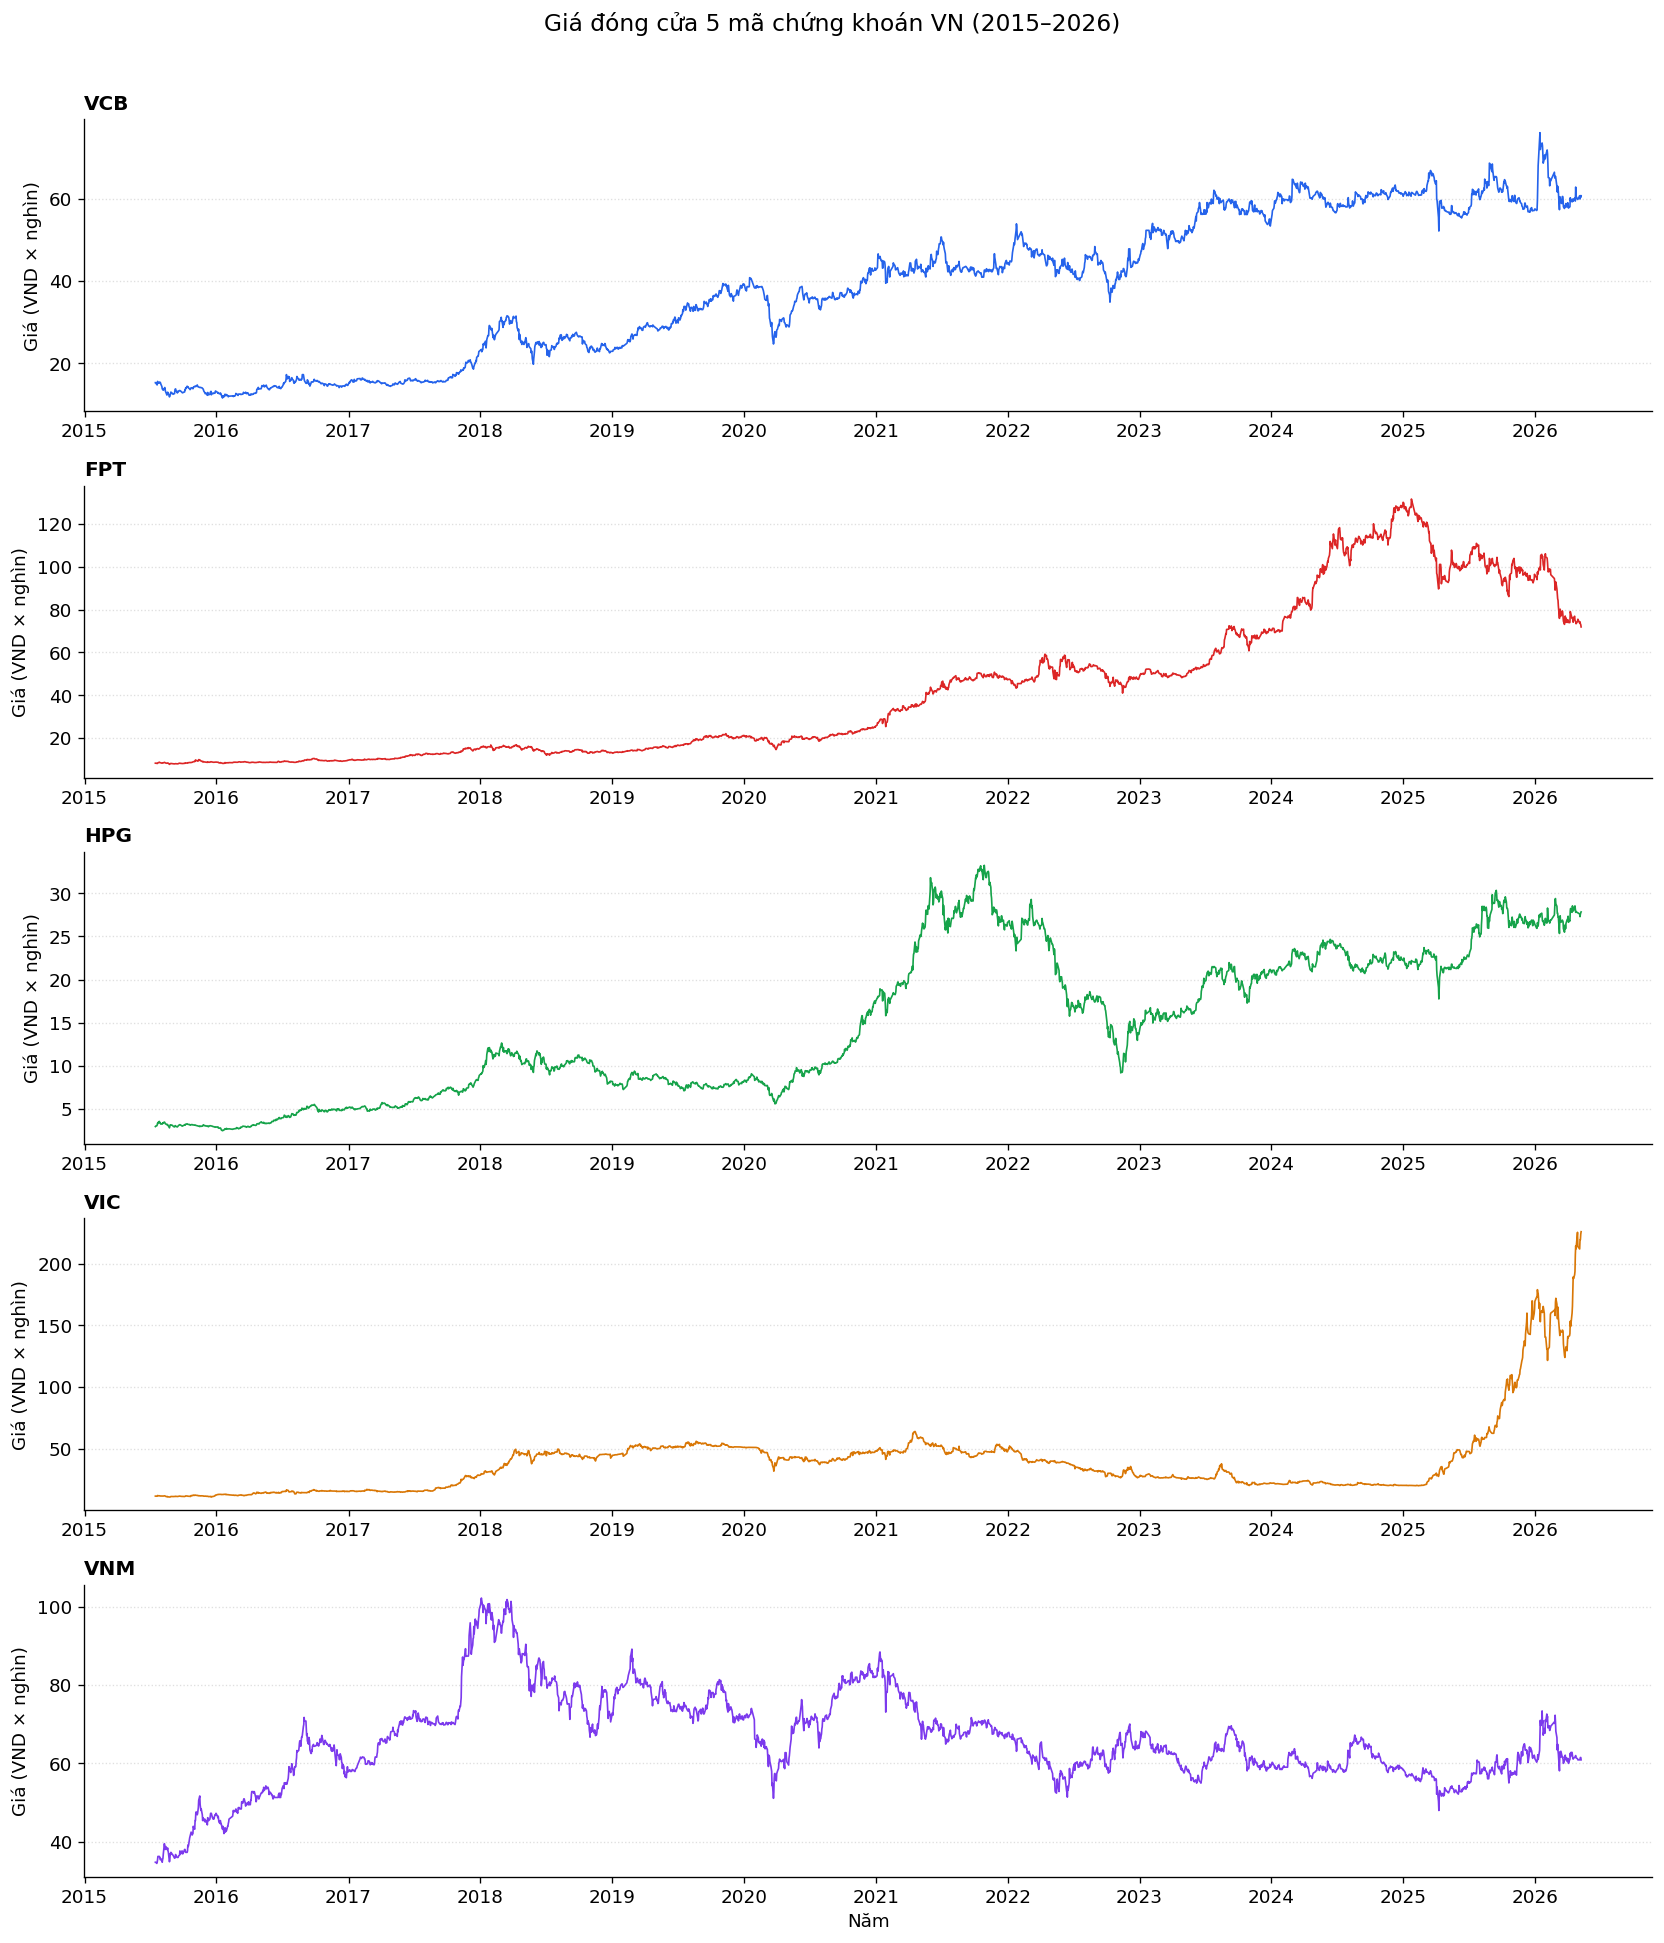

In [5]:
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=False)

for ax, ticker in zip(axes, TICKERS):
    df = raw[ticker].sort_values('date')
    ax.plot(df['date'], df['close'], color=COLORS[ticker], lw=1.0)
    ax.set_title(ticker, fontsize=12, fontweight='bold', loc='left')
    ax.set_ylabel('Giá (VND × nghìn)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.grid(axis='y', ls=':', alpha=0.4)

axes[-1].set_xlabel('Năm')
fig.suptitle('Giá đóng cửa 5 mã chứng khoán VN (2015–2026)', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(PLOTS_DIR / '01_close_price_all.png', dpi=150, bbox_inches='tight')
plt.show()

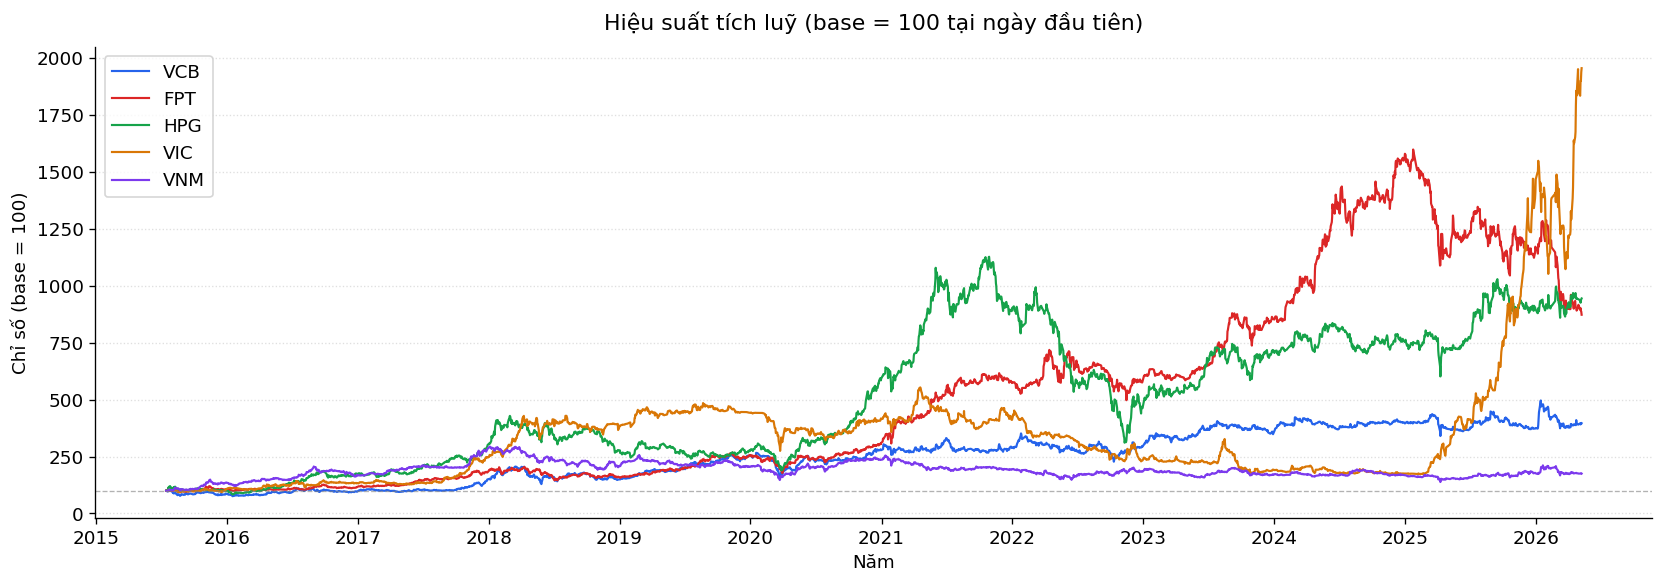

In [6]:
# Giá chuẩn hoá (base = 100) để so sánh hiệu suất tương đối
fig, ax = plt.subplots(figsize=(14, 5))

for ticker in TICKERS:
    df = raw[ticker].sort_values('date').dropna(subset=['close'])
    normalized = df['close'] / df['close'].iloc[0] * 100
    ax.plot(df['date'], normalized, label=ticker, color=COLORS[ticker], lw=1.3)

ax.axhline(100, color='gray', ls='--', lw=0.8, alpha=0.6)
ax.set_title('Hiệu suất tích luỹ (base = 100 tại ngày đầu tiên)', pad=10)
ax.set_ylabel('Chỉ số (base = 100)')
ax.set_xlabel('Năm')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(axis='y', ls=':', alpha=0.4)
plt.tight_layout()
fig.savefig(PLOTS_DIR / '02_normalized_price.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3 — Phân tích lợi suất hàng ngày (Daily Returns)

In [7]:
returns = {}
for t in TICKERS:
    df = raw[t].sort_values('date').dropna(subset=['close'])
    returns[t] = df.set_index('date')['close'].pct_change().dropna() * 100  # đơn vị %

# Thống kê lợi suất
ret_stats = pd.DataFrame({
    t: {
        'Mean (%)':     round(returns[t].mean(), 4),
        'Std (%)':      round(returns[t].std(), 4),
        'Skewness':     round(returns[t].skew(), 4),
        'Kurtosis':     round(returns[t].kurtosis(), 4),
        'Min (%)':      round(returns[t].min(), 4),
        'Max (%)':      round(returns[t].max(), 4),
    } for t in TICKERS
})
print('Thống kê lợi suất hàng ngày (%):')
print(ret_stats.to_string())

Thống kê lợi suất hàng ngày (%):
             VCB     FPT     HPG     VIC     VNM
Mean (%)  0.0664  0.0939  0.1045  0.1314  0.0325
Std (%)   1.7552  1.6567  2.0689  2.0692  1.5320
Skewness  0.1101  0.0678  0.0595  0.3404  0.2861
Kurtosis  2.8732  3.2757  1.8267  3.2405  3.5011
Min (%)  -7.0030 -6.9999 -7.0013 -7.0094 -7.0089
Max (%)   6.9702  6.9878  6.9136  7.0000  7.0171


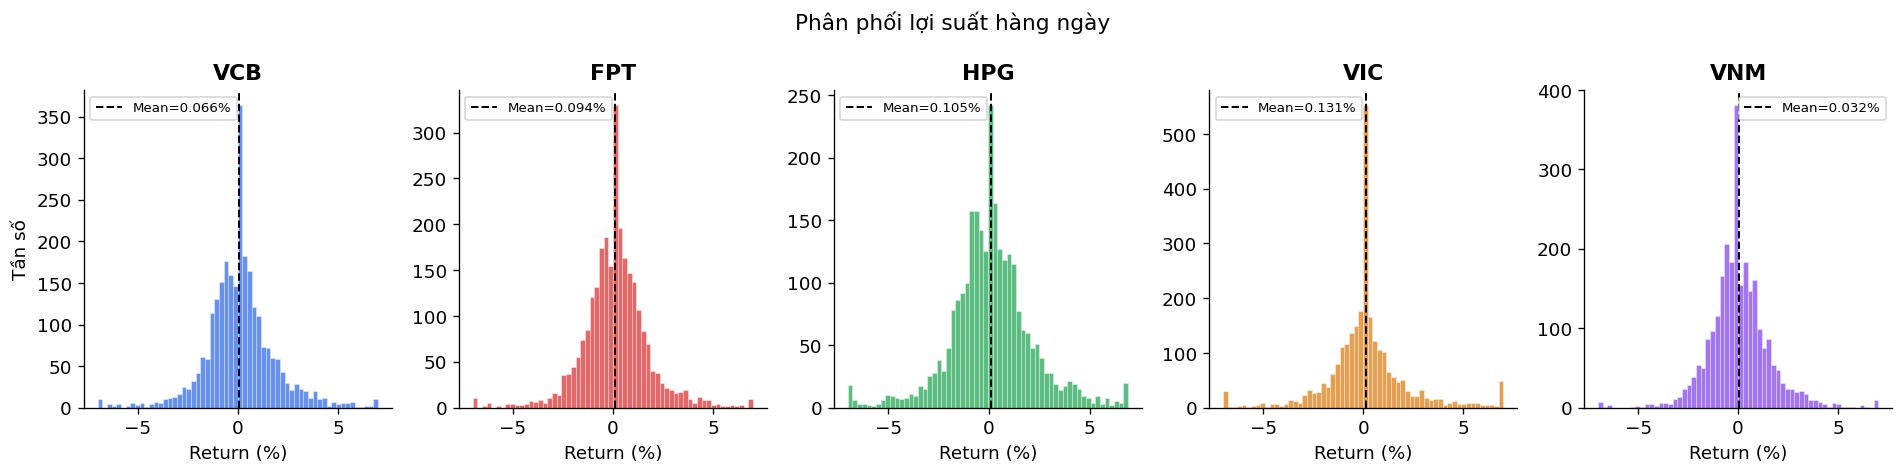

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=False)

for ax, ticker in zip(axes, TICKERS):
    r = returns[ticker]
    ax.hist(r, bins=60, color=COLORS[ticker], alpha=0.7, edgecolor='white', lw=0.3)
    ax.axvline(r.mean(), color='black', ls='--', lw=1.2, label=f'Mean={r.mean():.3f}%')
    ax.set_title(ticker, fontweight='bold')
    ax.set_xlabel('Return (%)')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Tần số')
fig.suptitle('Phân phối lợi suất hàng ngày', fontsize=13)
plt.tight_layout()
fig.savefig(PLOTS_DIR / '03_returns_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

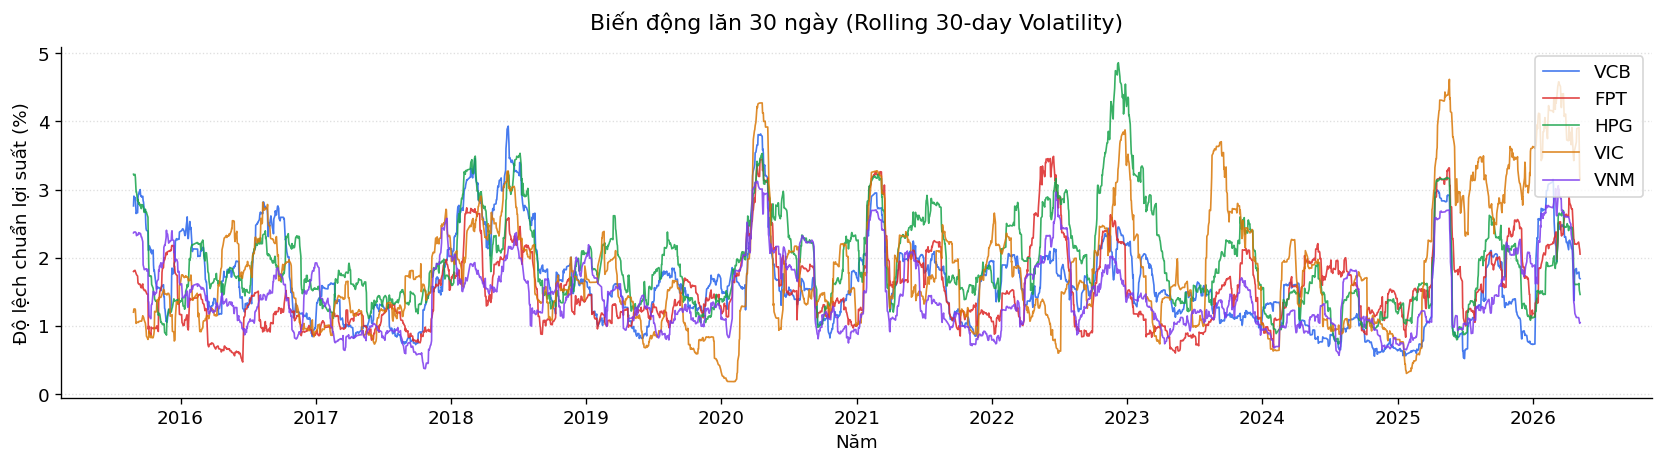

In [9]:
# Volatility rolling 30 ngày
fig, ax = plt.subplots(figsize=(14, 4))

for ticker in TICKERS:
    roll_vol = returns[ticker].rolling(30).std()
    ax.plot(roll_vol.index, roll_vol, label=ticker, color=COLORS[ticker], lw=1.0, alpha=0.85)

ax.set_title('Biến động lăn 30 ngày (Rolling 30-day Volatility)', pad=10)
ax.set_ylabel('Độ lệch chuẩn lợi suất (%)')
ax.set_xlabel('Năm')
ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(axis='y', ls=':', alpha=0.4)
plt.tight_layout()
fig.savefig(PLOTS_DIR / '04_rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4 — Ma trận tương quan

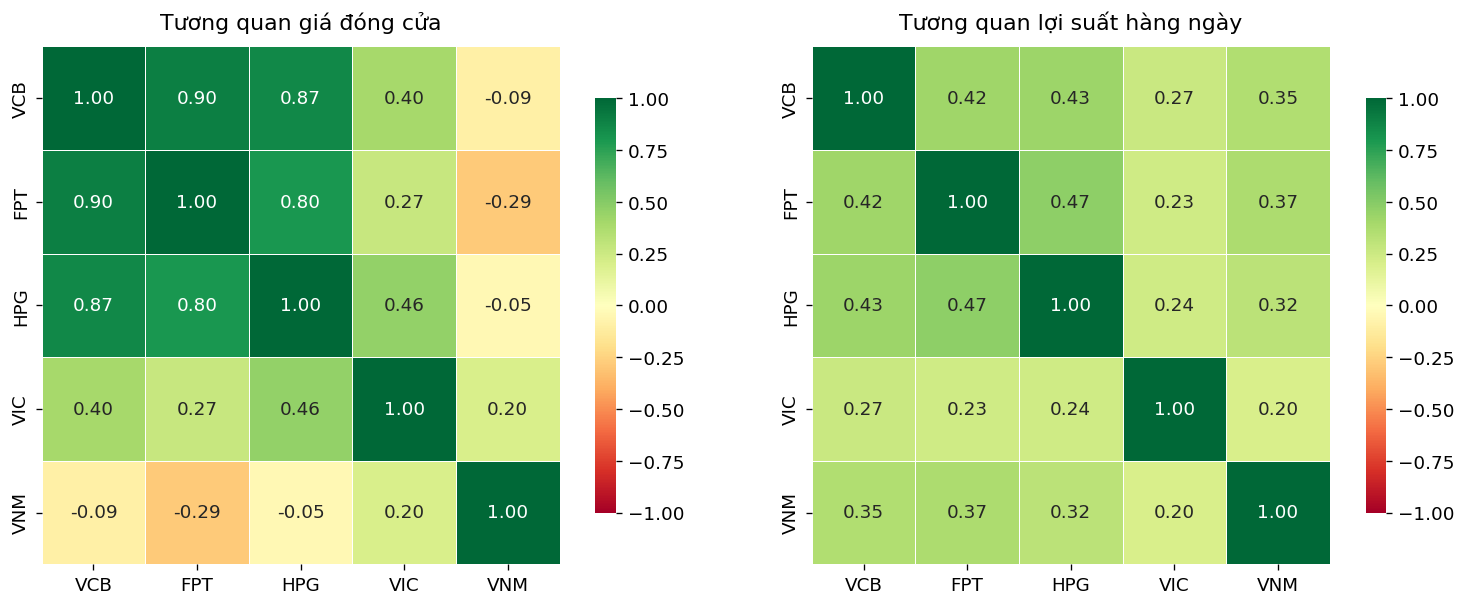

In [10]:
# Tương quan giá đóng cửa
price_df  = pd.DataFrame({t: raw[t].set_index('date')['close'] for t in TICKERS}).dropna()
return_df = price_df.pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, title in [
    (axes[0], price_df.corr(),  'Tương quan giá đóng cửa'),
    (axes[1], return_df.corr(), 'Tương quan lợi suất hàng ngày'),
]:
    sns.heatmap(
        df, annot=True, fmt='.2f', cmap='RdYlGn',
        vmin=-1, vmax=1, center=0,
        square=True, linewidths=0.5,
        ax=ax, cbar_kws={'shrink': 0.8},
    )
    ax.set_title(title, pad=10)

plt.tight_layout()
fig.savefig(PLOTS_DIR / '05_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5 — Kiểm định tính dừng (ADF Test)

**Augmented Dickey-Fuller Test**  
- H₀: chuỗi có nghiệm đơn vị (không dừng)  
- H₁: chuỗi dừng  
- Bác bỏ H₀ khi **p-value < 0.05**

In [11]:
def run_adf(series: pd.Series, name: str) -> dict:
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'Chuỗi':       name,
        'ADF Stat':    round(result[0], 4),
        'p-value':     round(result[1], 6),
        'Lags':        result[2],
        'Critical 1%': round(result[4]['1%'], 4),
        'Critical 5%': round(result[4]['5%'], 4),
        'Dừng?':       '✅ Có' if result[1] < 0.05 else '❌ Không',
    }

adf_rows = []
for ticker in TICKERS:
    series = raw[ticker].sort_values('date').set_index('date')['close']
    adf_rows.append(run_adf(series,                   f'{ticker} (giá)'))
    adf_rows.append(run_adf(series.pct_change() * 100, f'{ticker} (lợi suất)'))

adf_df = pd.DataFrame(adf_rows)
print(adf_df.to_string(index=False))

         Chuỗi  ADF Stat  p-value  Lags  Critical 1%  Critical 5%   Dừng?
     VCB (giá)   -1.0700 0.726893     3      -3.4328      -2.8626 ❌ Không
VCB (lợi suất)  -31.3534 0.000000     2      -3.4328      -2.8626    ✅ Có
     FPT (giá)   -0.8306 0.809965    28      -3.4328      -2.8626 ❌ Không
FPT (lợi suất)  -38.1824 0.000000     1      -3.4328      -2.8626    ✅ Có
     HPG (giá)   -1.0156 0.747524    16      -3.4328      -2.8626 ❌ Không
HPG (lợi suất)  -13.1780 0.000000    12      -3.4328      -2.8626    ✅ Có
     VIC (giá)    4.3323 1.000000    27      -3.4328      -2.8626 ❌ Không
VIC (lợi suất)  -21.3845 0.000000     4      -3.4328      -2.8626    ✅ Có
     VNM (giá)   -2.8995 0.045407     4      -3.4328      -2.8626    ✅ Có
VNM (lợi suất)  -28.0574 0.000000     3      -3.4328      -2.8626    ✅ Có


**Nhận xét:** Chuỗi giá thường không dừng (p > 0.05), chuỗi lợi suất dừng (p < 0.05). Đây là đặc tính điển hình của dữ liệu chứng khoán — cần lưu ý khi áp dụng ARIMA.

---
## 6 — Phân rã chuỗi thời gian (Seasonal Decomposition)

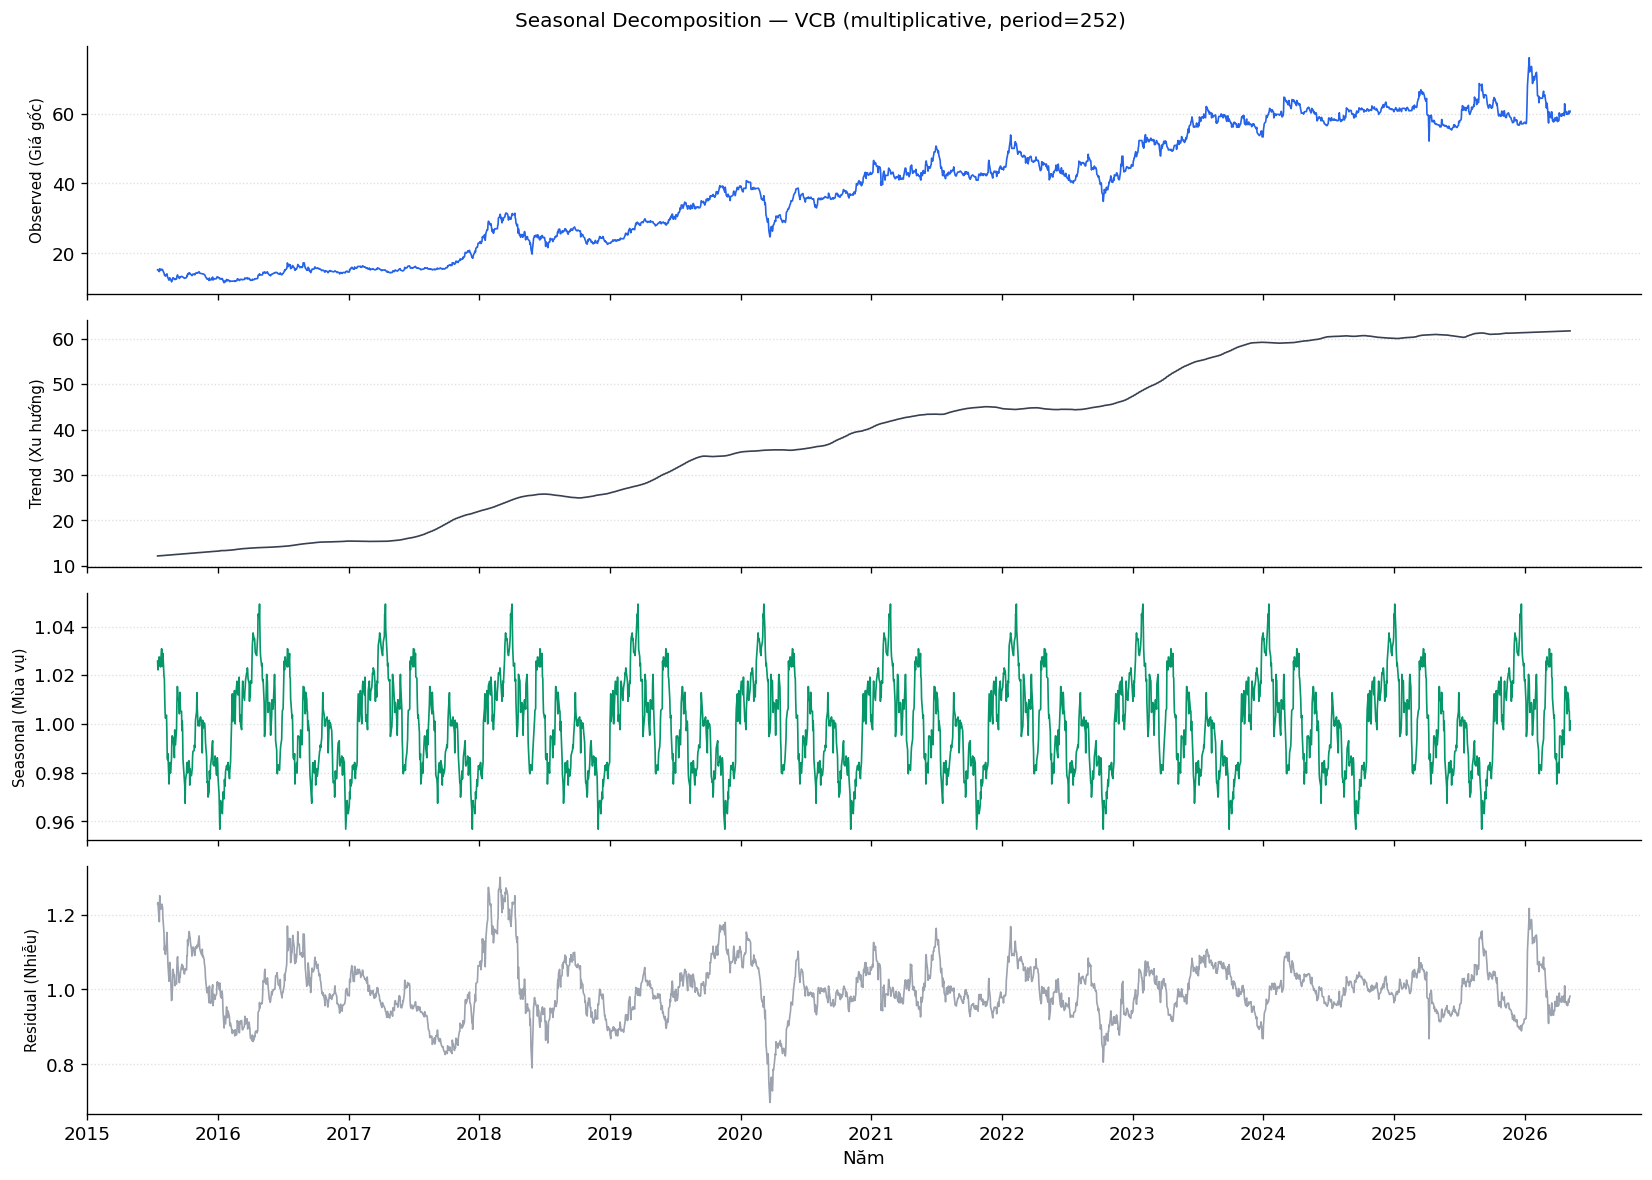

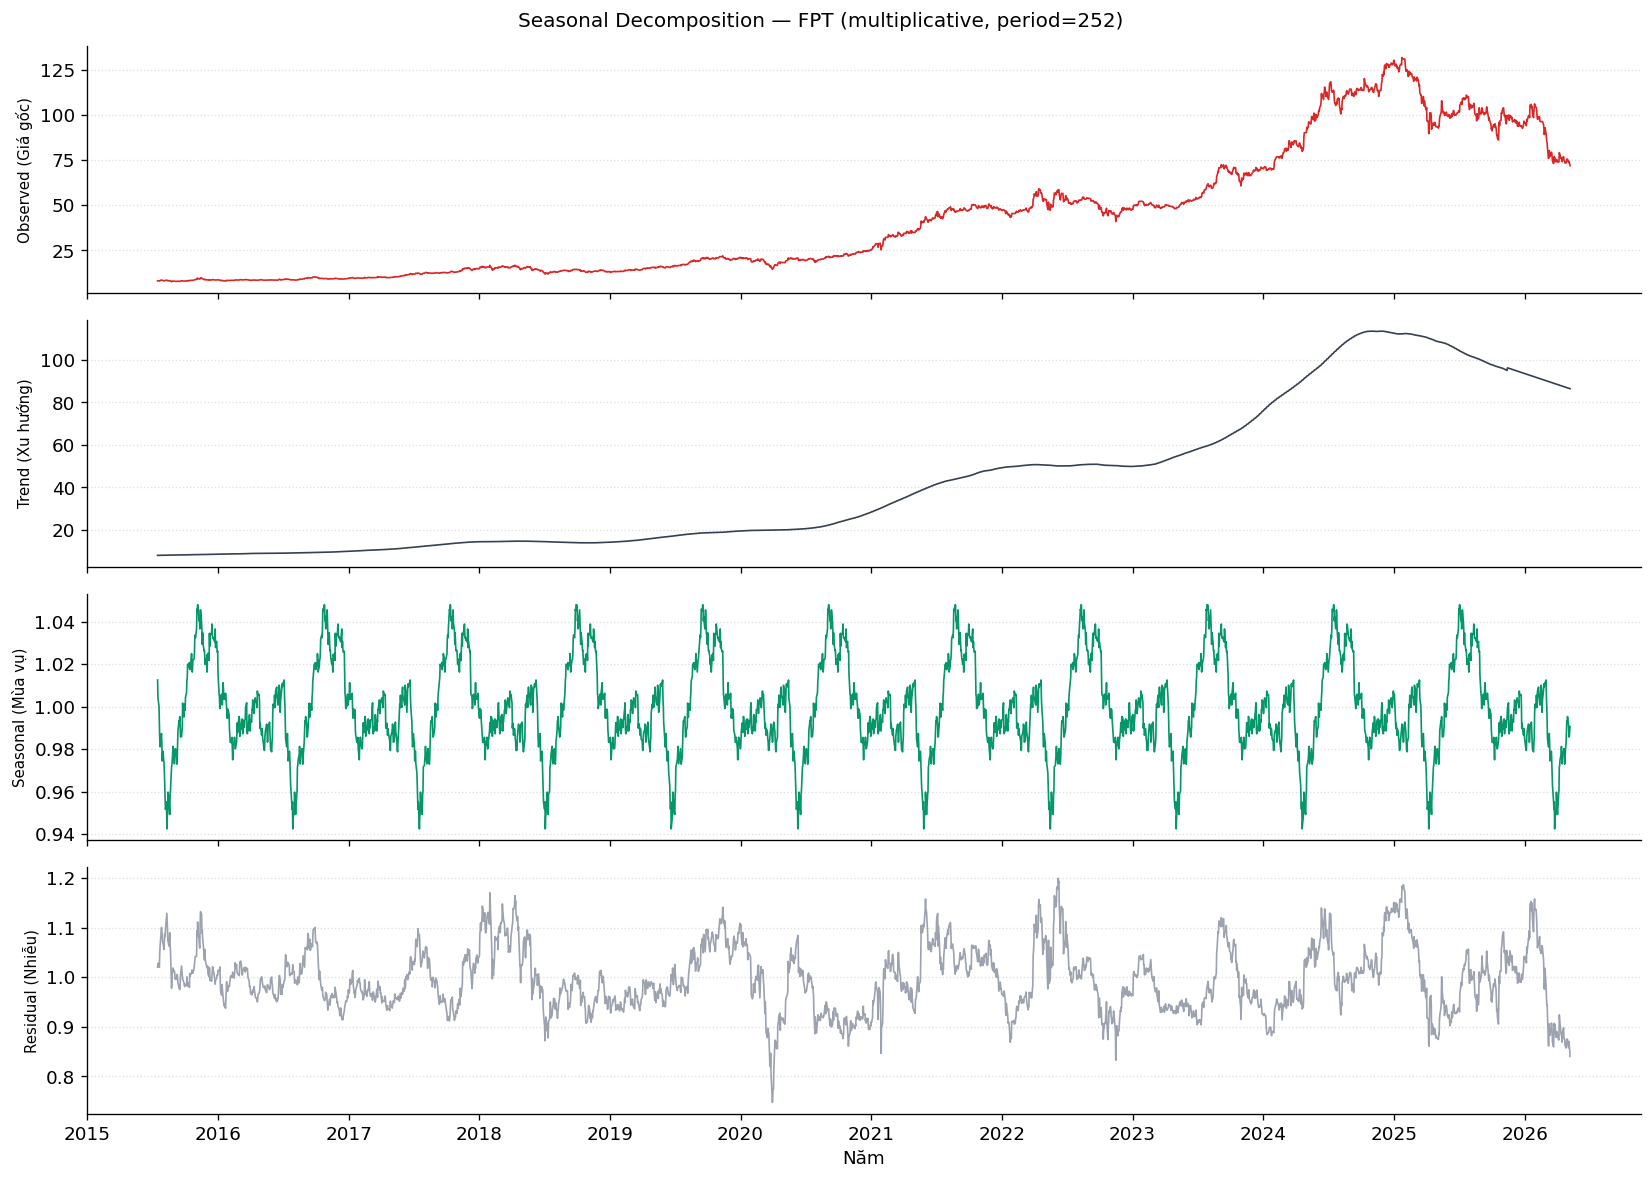

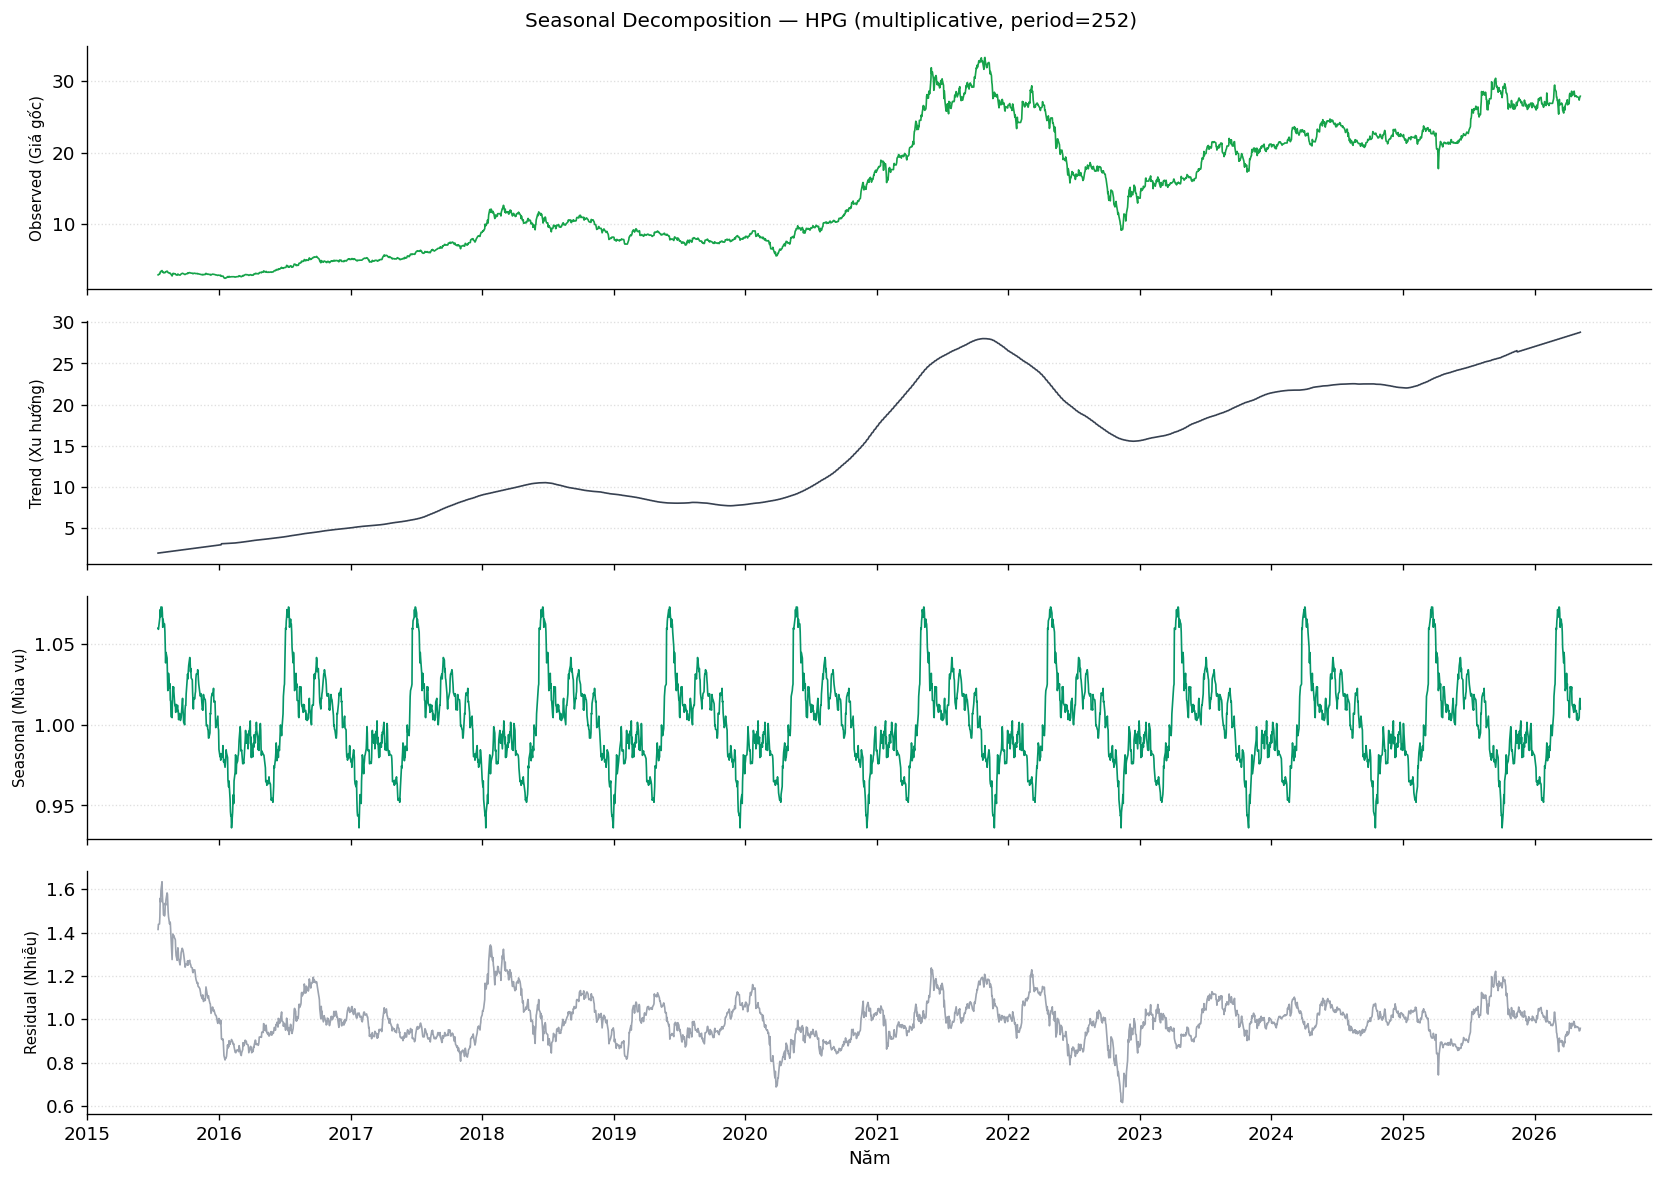

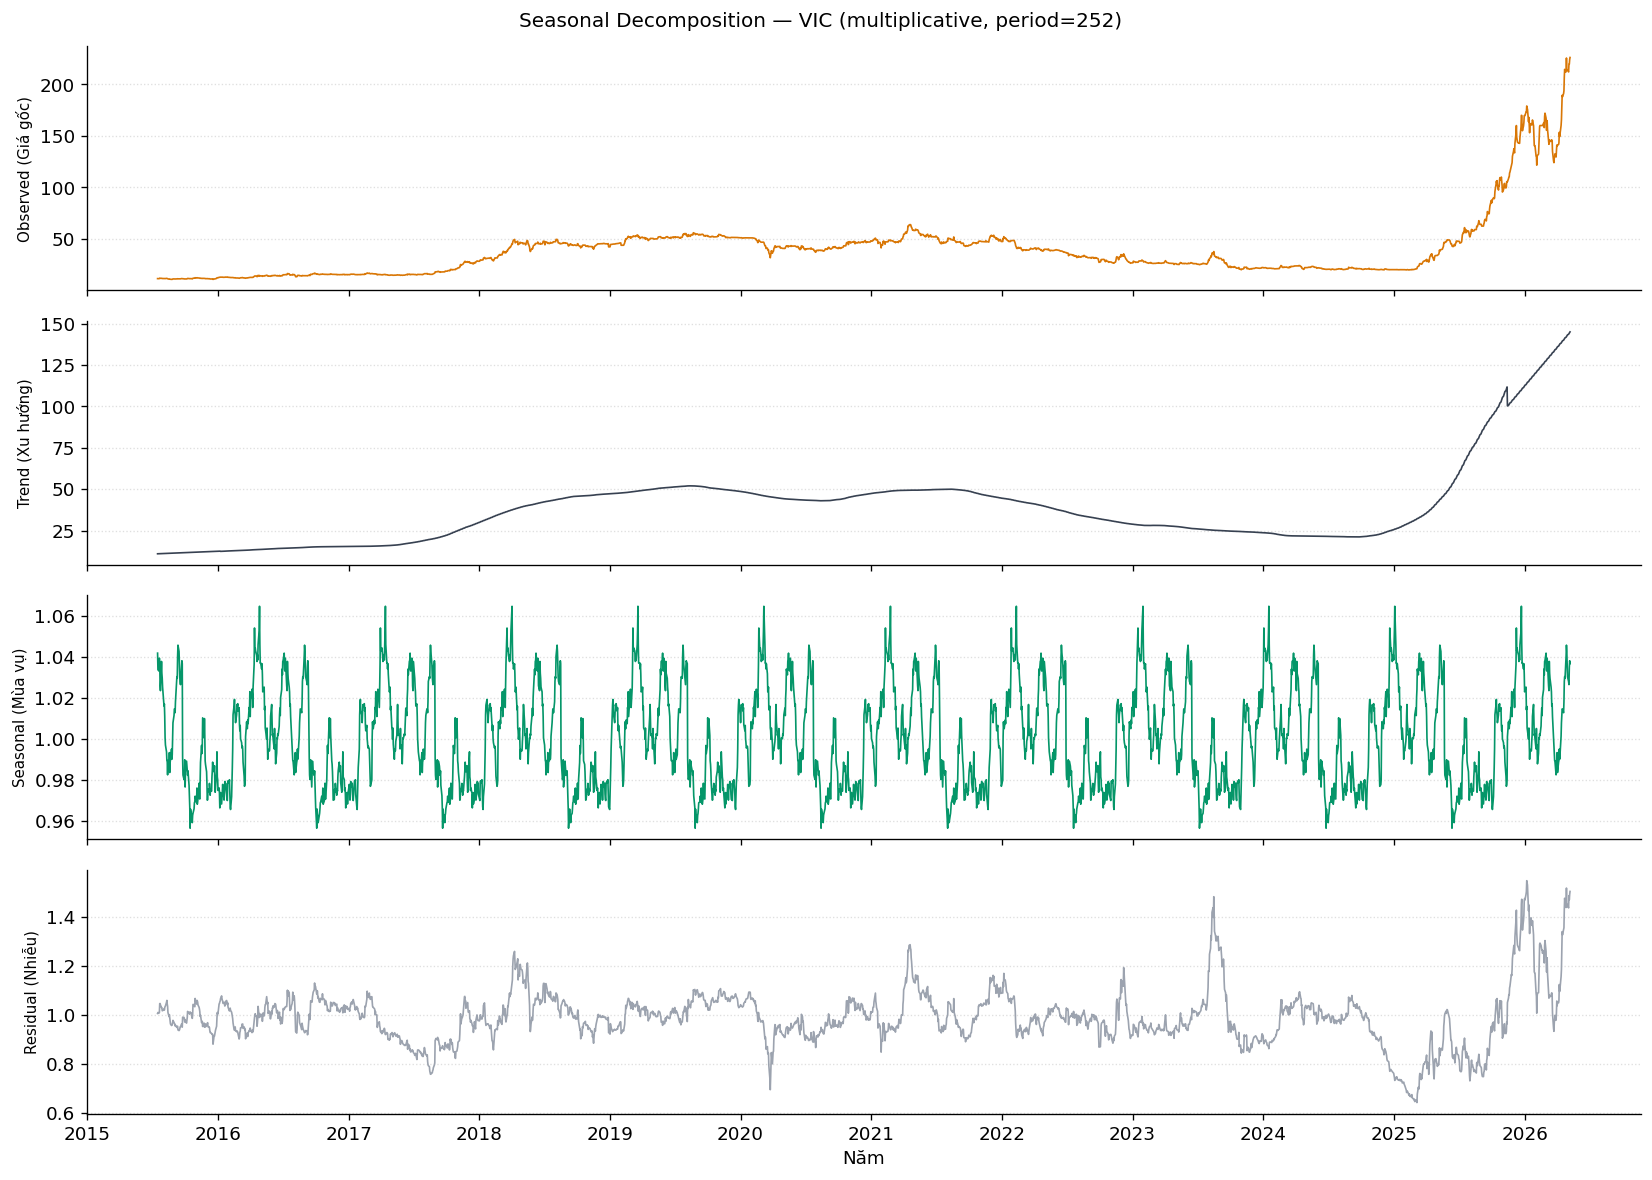

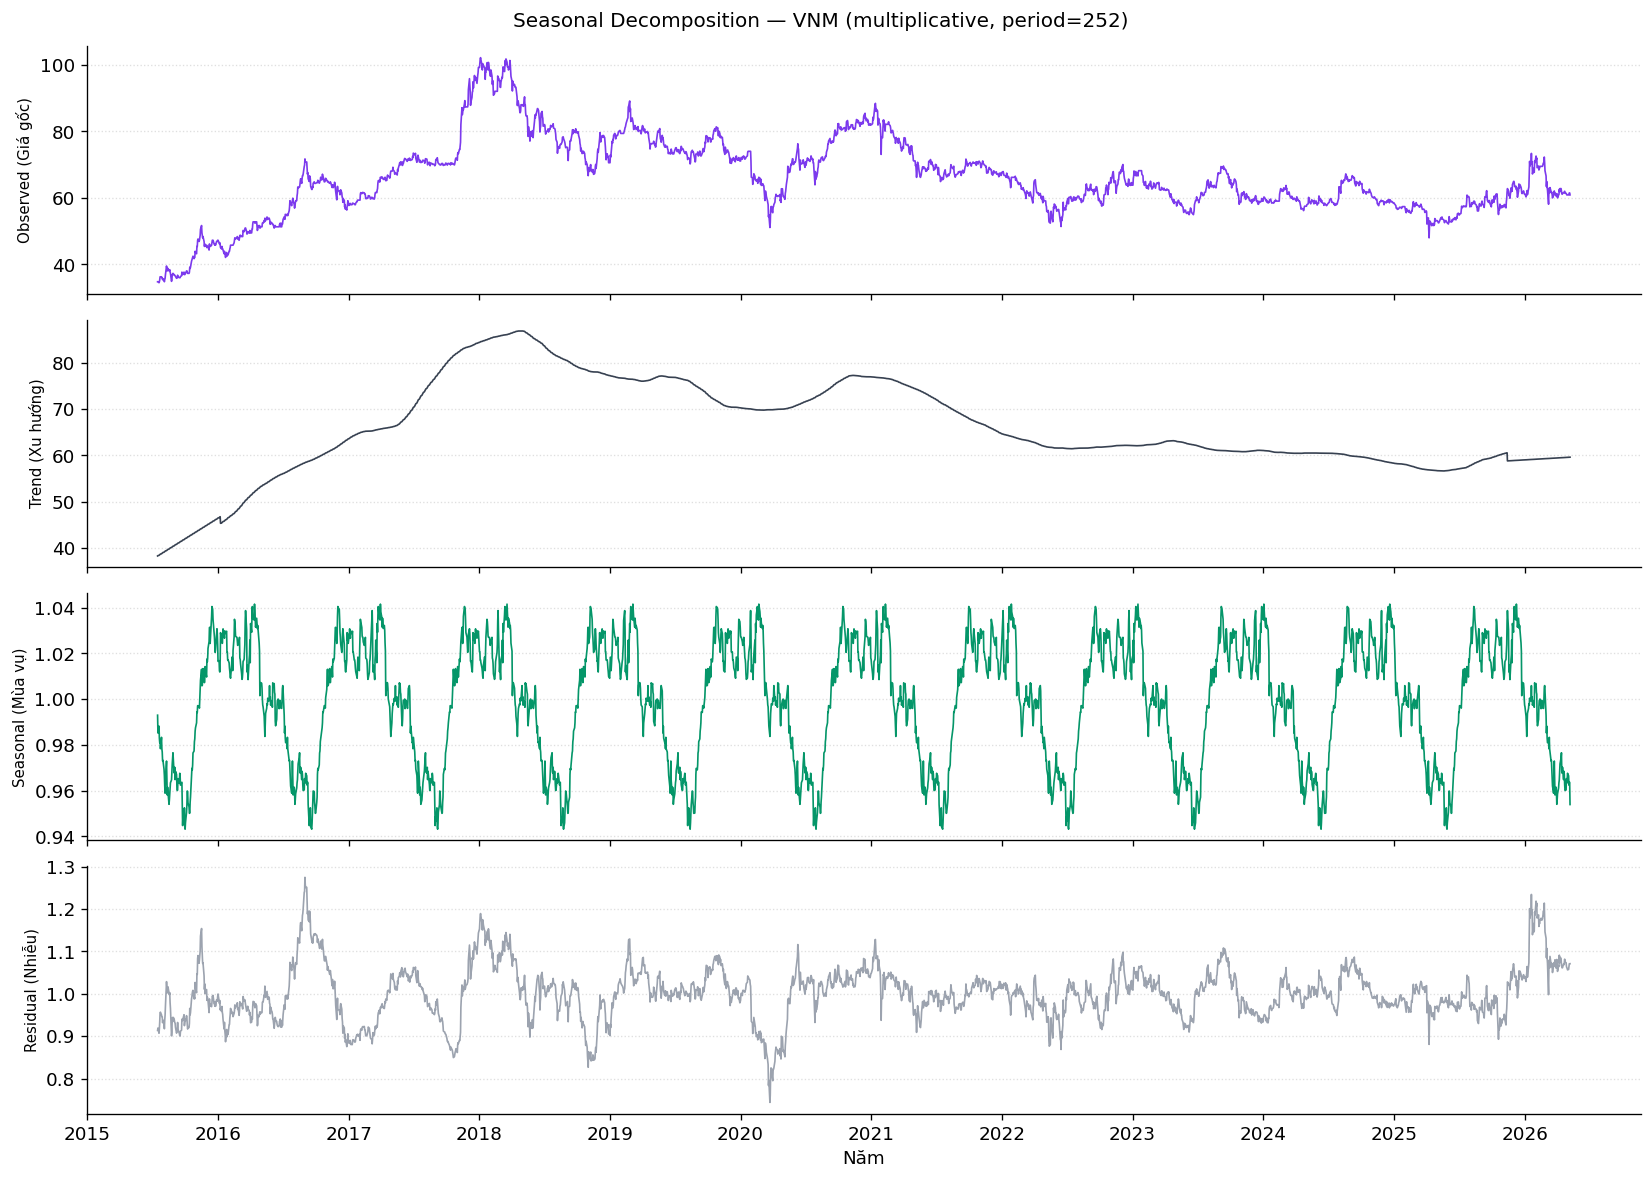

In [12]:
# Phân rã cho từng mã — period=252 (xấp xỉ số phiên giao dịch/năm)
PERIOD = 252

for ticker in TICKERS:
    series = (
        raw[ticker].sort_values('date')
        .set_index('date')['close']
        .dropna()
        .asfreq('B')           # Business day frequency
        .ffill()               # Fill gaps từ holidays
    )

    decomp = seasonal_decompose(series, model='multiplicative', period=PERIOD, extrapolate_trend='freq')

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    components = [
        (series,            'Observed (Giá gốc)', COLORS[ticker]),
        (decomp.trend,      'Trend (Xu hướng)',   '#374151'),
        (decomp.seasonal,   'Seasonal (Mùa vụ)',  '#059669'),
        (decomp.resid,      'Residual (Nhiễu)',   '#9CA3AF'),
    ]
    for ax, (data, label, color) in zip(axes, components):
        ax.plot(data.index, data.values, color=color, lw=1.0)
        ax.set_ylabel(label, fontsize=9)
        ax.grid(axis='y', ls=':', alpha=0.4)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[-1].xaxis.set_major_locator(mdates.YearLocator())
    axes[-1].set_xlabel('Năm')
    fig.suptitle(f'Seasonal Decomposition — {ticker} (multiplicative, period=252)', fontsize=12)
    plt.tight_layout()
    fig.savefig(PLOTS_DIR / f'06_decomposition_{ticker}.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 7 — Trực quan hoá chỉ số kỹ thuật

Minh hoạ trên mã **VCB** — 2 năm gần nhất để dễ đọc.

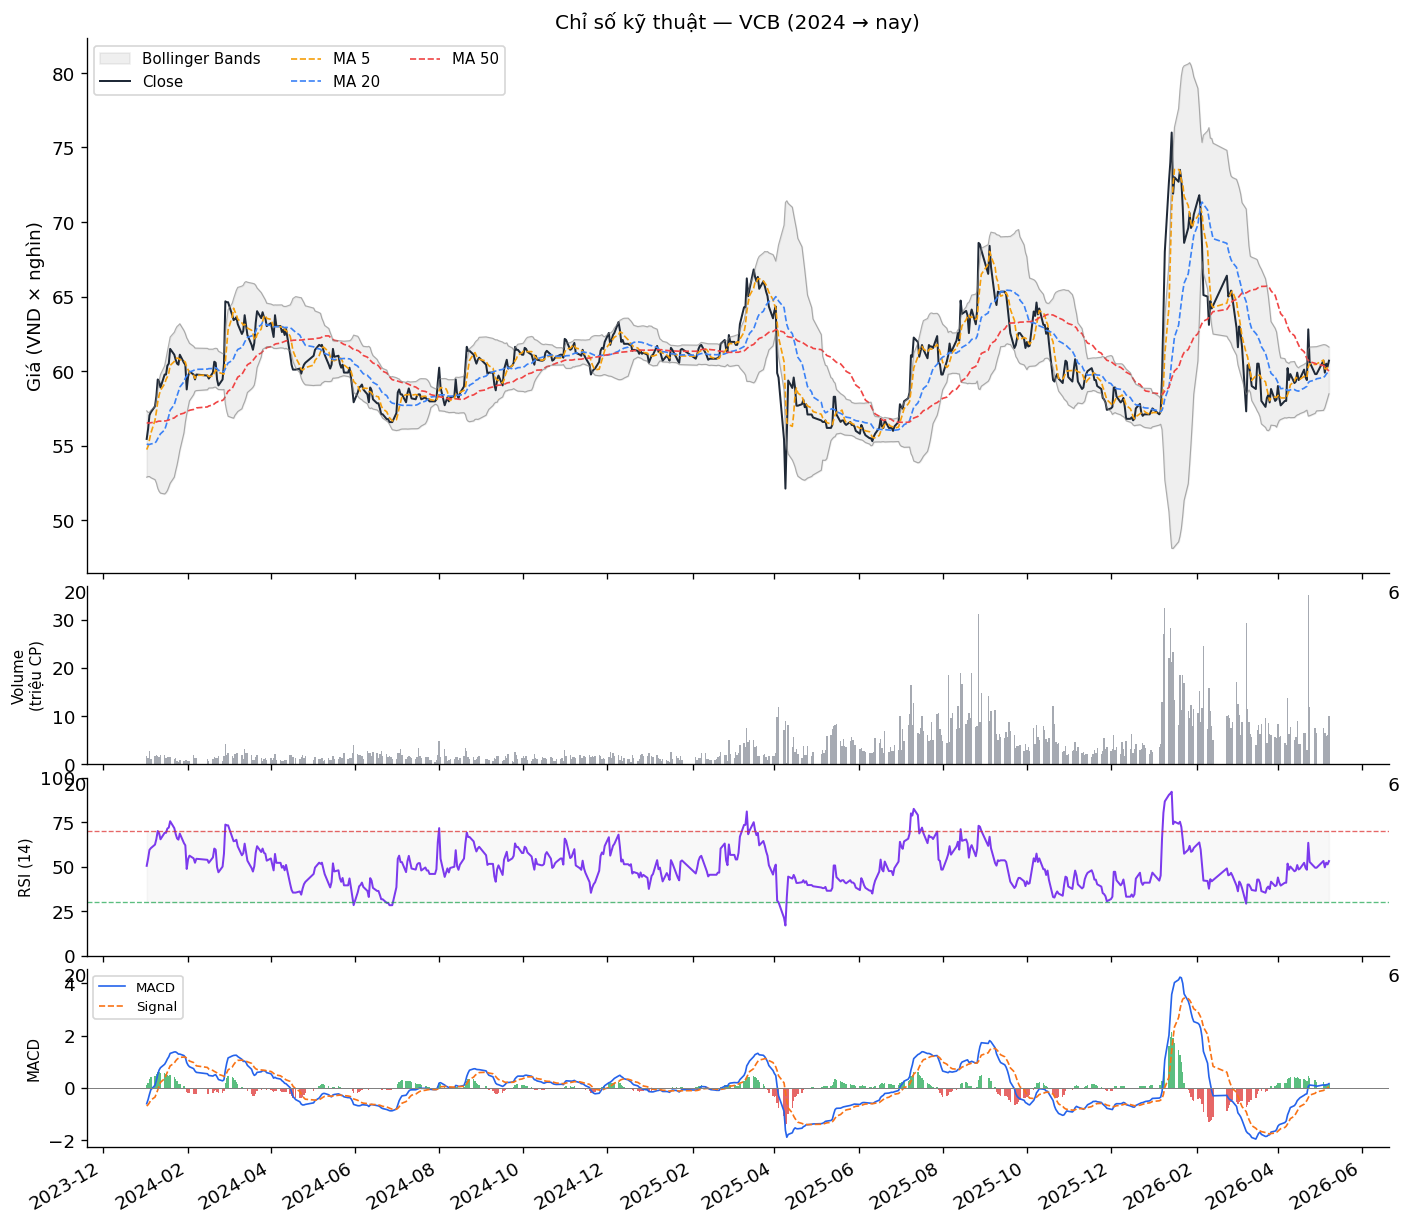

In [13]:
DEMO_TICKER = 'VCB'
df_feat = featured[DEMO_TICKER].sort_values('date')
df_2y   = df_feat[df_feat['date'] >= '2024-01-01'].copy()

fig = plt.figure(figsize=(14, 12))
gs  = gridspec.GridSpec(4, 1, figure=fig, hspace=0.05, height_ratios=[3, 1, 1, 1])

# ── Panel 1: Giá + MA + Bollinger Bands ──
ax1 = fig.add_subplot(gs[0])
ax1.fill_between(df_2y['date'], df_2y['bb_lower'], df_2y['bb_upper'],
                 alpha=0.12, color='gray', label='Bollinger Bands')
ax1.plot(df_2y['date'], df_2y['close'],     color='#1F2937', lw=1.2, label='Close')
ax1.plot(df_2y['date'], df_2y['ma_5'],      color='#F59E0B', lw=1.0, ls='--', label='MA 5')
ax1.plot(df_2y['date'], df_2y['ma_20'],     color='#3B82F6', lw=1.0, ls='--', label='MA 20')
ax1.plot(df_2y['date'], df_2y['ma_50'],     color='#EF4444', lw=1.0, ls='--', label='MA 50')
ax1.plot(df_2y['date'], df_2y['bb_upper'],  color='gray',    lw=0.7, alpha=0.6)
ax1.plot(df_2y['date'], df_2y['bb_lower'],  color='gray',    lw=0.7, alpha=0.6)
ax1.set_ylabel('Giá (VND × nghìn)')
ax1.legend(loc='upper left', fontsize=9, ncol=3)
ax1.set_title(f'Chỉ số kỹ thuật — {DEMO_TICKER} (2024 → nay)', fontsize=12)
ax1.set_xticklabels([])

# ── Panel 2: Volume ──
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.bar(df_2y['date'], df_2y['volume'] / 1e6, color='#6B7280', alpha=0.6, width=1)
ax2.set_ylabel('Volume\n(triệu CP)', fontsize=9)
ax2.set_xticklabels([])

# ── Panel 3: RSI ──
ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax3.plot(df_2y['date'], df_2y['rsi_14'], color='#7C3AED', lw=1.2)
ax3.axhline(70, color='#DC2626', ls='--', lw=0.8, alpha=0.7)
ax3.axhline(30, color='#16A34A', ls='--', lw=0.8, alpha=0.7)
ax3.fill_between(df_2y['date'], 30, 70, alpha=0.05, color='gray')
ax3.set_ylim(0, 100)
ax3.set_ylabel('RSI (14)', fontsize=9)
ax3.set_xticklabels([])

# ── Panel 4: MACD ──
ax4 = fig.add_subplot(gs[3], sharex=ax1)
ax4.bar(df_2y['date'], df_2y['macd_hist'],
        color=np.where(df_2y['macd_hist'] >= 0, '#16A34A', '#DC2626'),
        alpha=0.7, width=1)
ax4.plot(df_2y['date'], df_2y['macd'],        color='#2563EB', lw=1.0, label='MACD')
ax4.plot(df_2y['date'], df_2y['macd_signal'], color='#F97316', lw=1.0, ls='--', label='Signal')
ax4.axhline(0, color='gray', lw=0.6)
ax4.set_ylabel('MACD', fontsize=9)
ax4.legend(loc='upper left', fontsize=8)
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.savefig(PLOTS_DIR / f'07_technical_indicators_{DEMO_TICKER}.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8 — Điều tra outlier — Trường hợp VIC

Mục đích: phát hiện các phiên biến động bất thường có thể ảnh hưởng đến độ tin cậy của model. **VIC** được chọn vì:
- ADF p-value của giá VIC = 1.0000 (Section 5) — chuỗi gần như random walk thuần tuý, không có cấu trúc trend
- Walk-forward 5-fold (Chương 5): VIC fold cuối có RMSE ≈ 3.34 trong khi các fold khác chỉ 0.5–0.9 → cần điều tra nguyên nhân

Phân tích 3 góc:
1. **Top-10 phiên |return| lớn nhất** trên cả 5 mã — nhận diện ngày có biến động cực điểm
2. **Volatility từ 2024** — so sánh VIC với 4 mã còn lại trong giai đoạn test gần đây
3. **VIC chi tiết** — giá + outlier marker + rolling vol vs benchmark


Top 10 phiên có |daily return| lớn nhất (5 mã, toàn kỳ):
      date ticker  close  return_pct
2015-08-10    VNM  39.50        7.02
2018-07-03    VIC  44.31       -7.01
2020-03-23    VNM  51.08       -7.01
2020-03-23    VCB  24.70       -7.00
2025-04-03    HPG  21.12       -7.00
2025-04-08    VCB  55.40       -7.00
2025-12-10    VIC 148.80       -7.00
2023-09-25    VIC  23.25       -7.00
2025-05-19    VIC  42.80        7.00
2025-04-08    FPT  89.68       -7.00

Volatility từ 2024 (so sánh 5 mã):
        Std return (%)  Max |return| (%)
ticker                                  
FPT              1.852             7.000
HPG              1.676             7.001
VCB              1.504             7.000
VIC              2.680             7.000
VNM              1.559             6.951


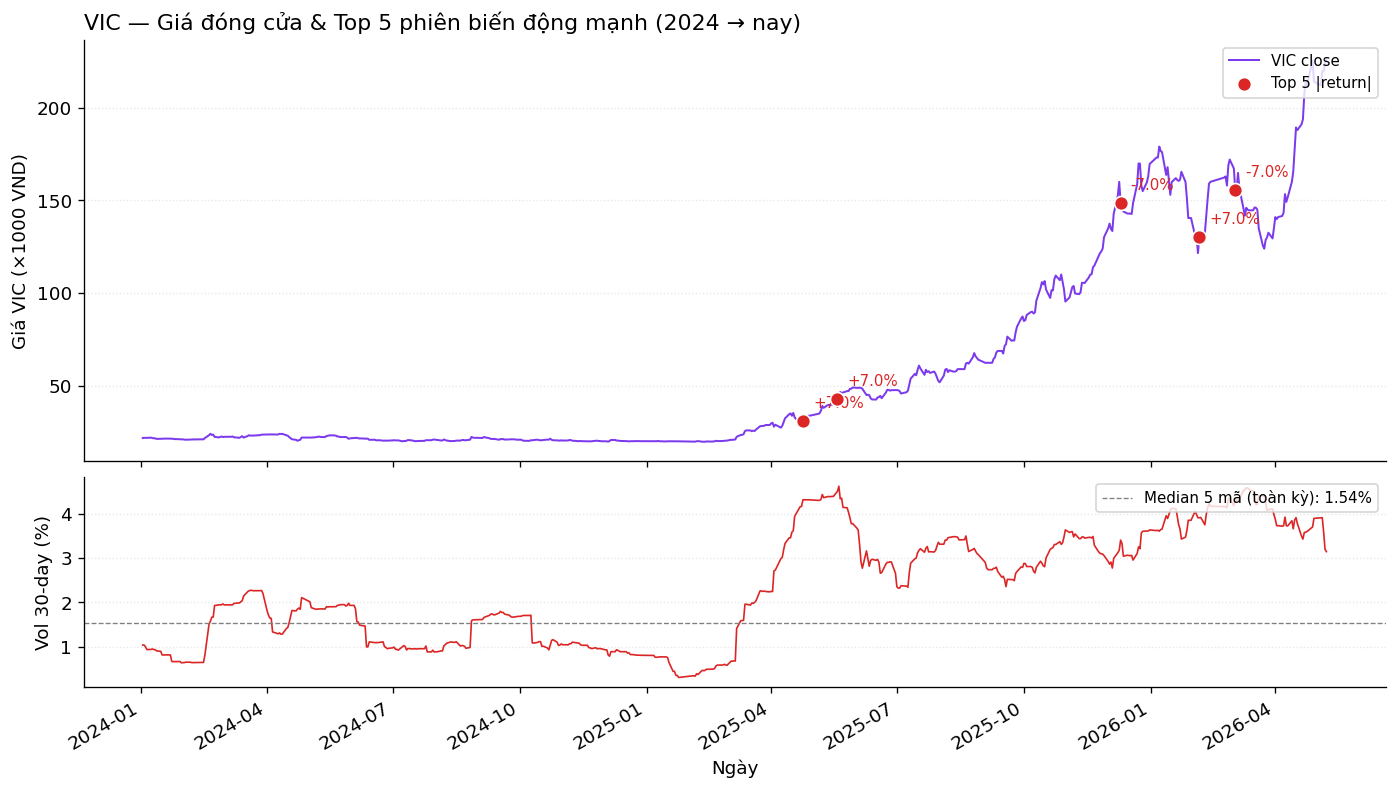

In [14]:
# ── Tính lợi suất + rolling vol cho cả 5 mã ──
returns_panel = []
for t in TICKERS:
    df = raw[t].sort_values('date').copy()
    df['return_pct'] = df['close'].pct_change() * 100
    df['vol_30d']    = df['return_pct'].rolling(30).std()
    df['ticker']     = t
    returns_panel.append(df[['date', 'ticker', 'close', 'return_pct', 'vol_30d']])
panel = pd.concat(returns_panel, ignore_index=True)

# ── 1. Top-10 phiên có |return| lớn nhất (5 mã, toàn kỳ) ──
top10 = (panel.dropna(subset=['return_pct'])
              .reindex(panel['return_pct'].abs().sort_values(ascending=False).index)
              .head(10)
              .copy())
top10['date'] = top10['date'].dt.date
print('Top 10 phiên có |daily return| lớn nhất (5 mã, toàn kỳ):')
print(top10[['date', 'ticker', 'close', 'return_pct']].round(2).to_string(index=False))

# ── 2. So sánh volatility 2024+ giữa 5 mã ──
recent_vol = (panel[panel['date'] >= '2024-01-01']
              .groupby('ticker')['return_pct']
              .agg(['std', lambda x: x.abs().max()])
              .rename(columns={'std': 'Std return (%)', '<lambda_0>': 'Max |return| (%)'})
              .round(3))
print('\nVolatility từ 2024 (so sánh 5 mã):')
print(recent_vol.to_string())

# ── 3. Visualize VIC chi tiết: giá + đánh dấu top-5 outlier + rolling vol ──
vic = panel[panel['ticker'] == 'VIC'].copy()
vic_recent = vic[vic['date'] >= '2024-01-01'].copy()
top5_vic = (vic_recent.dropna(subset=['return_pct'])
            .reindex(vic_recent['return_pct'].abs().sort_values(ascending=False).index)
            .head(5))

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.05})
ax1, ax2 = axes

ax1.plot(vic_recent['date'], vic_recent['close'], color='#7C3AED', lw=1.2, label='VIC close')
ax1.scatter(top5_vic['date'], top5_vic['close'], c='#DC2626', s=70, zorder=5,
            label='Top 5 |return|', edgecolor='white')
for _, r in top5_vic.iterrows():
    ax1.annotate(f'{r["return_pct"]:+.1f}%', (r['date'], r['close']),
                 xytext=(6, 8), textcoords='offset points', fontsize=9, color='#DC2626')
ax1.set_ylabel('Giá VIC (×1000 VND)')
ax1.set_title('VIC — Giá đóng cửa & Top 5 phiên biến động mạnh (2024 → nay)', loc='left')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(axis='y', ls=':', alpha=0.3)

benchmark = panel['vol_30d'].median()
ax2.plot(vic_recent['date'], vic_recent['vol_30d'], color='#DC2626', lw=1.0)
ax2.axhline(benchmark, color='gray', ls='--', lw=0.8,
            label=f'Median 5 mã (toàn kỳ): {benchmark:.2f}%')
ax2.set_ylabel('Vol 30-day (%)')
ax2.set_xlabel('Ngày')
ax2.legend(loc='upper right', fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax2.grid(axis='y', ls=':', alpha=0.3)

fig.savefig(PLOTS_DIR / '08_vic_volatility.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9 — Phân chia Train / Test

Hai góc nhìn:
- **Single split** (70/30 và 80/20) — định nghĩa boundary cho báo cáo Chương 5 chính
- **Walk-forward 5-fold** (sau cùng) — 5 expanding window cho benchmark stability ở Chương 5


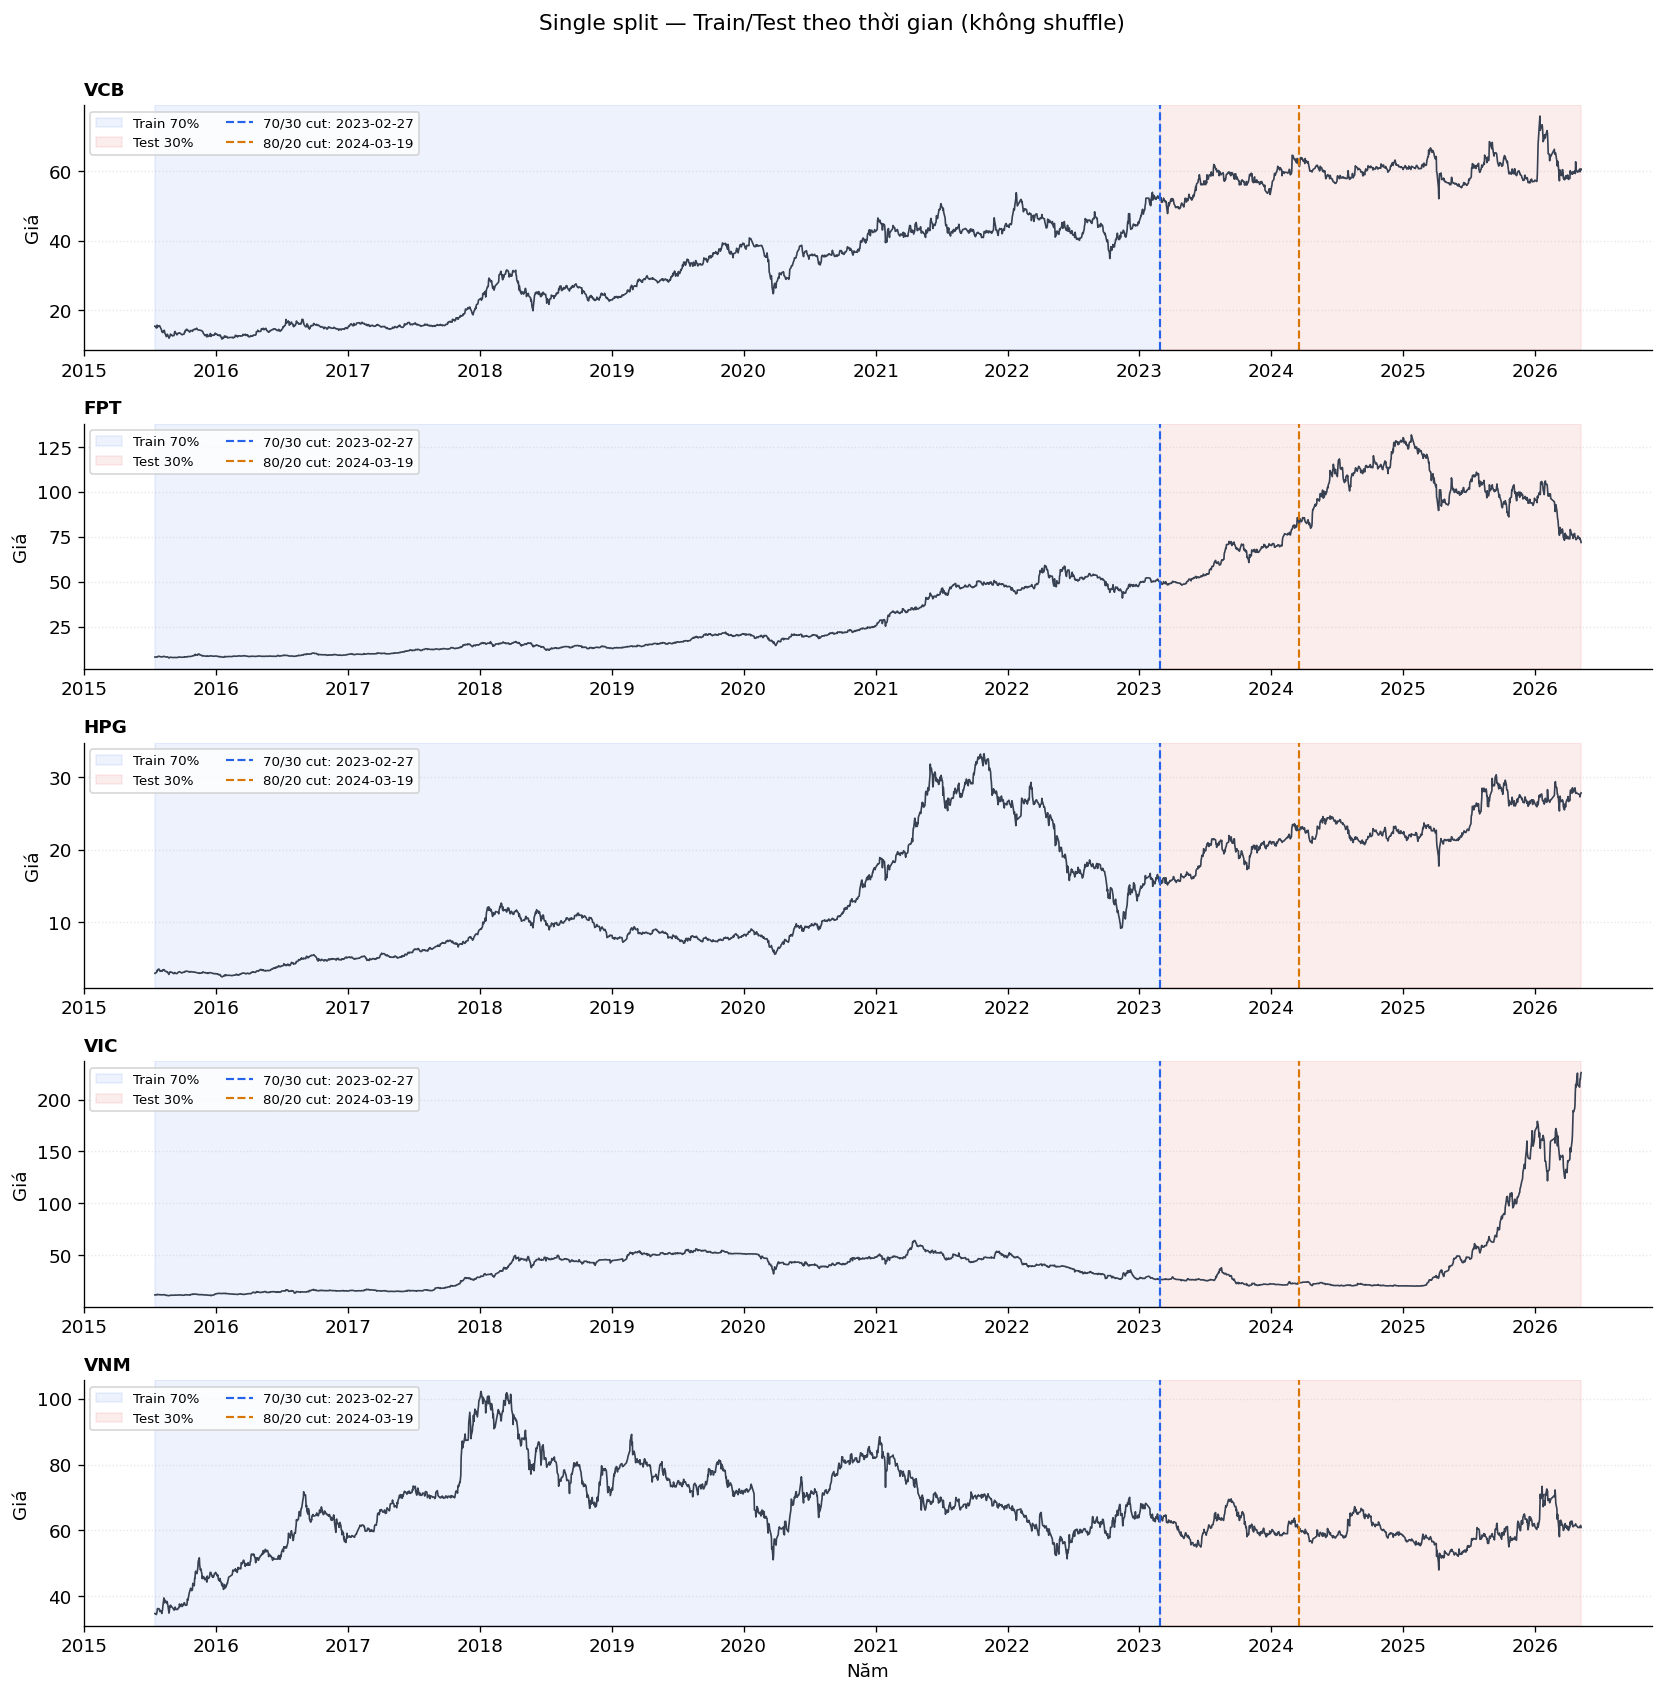

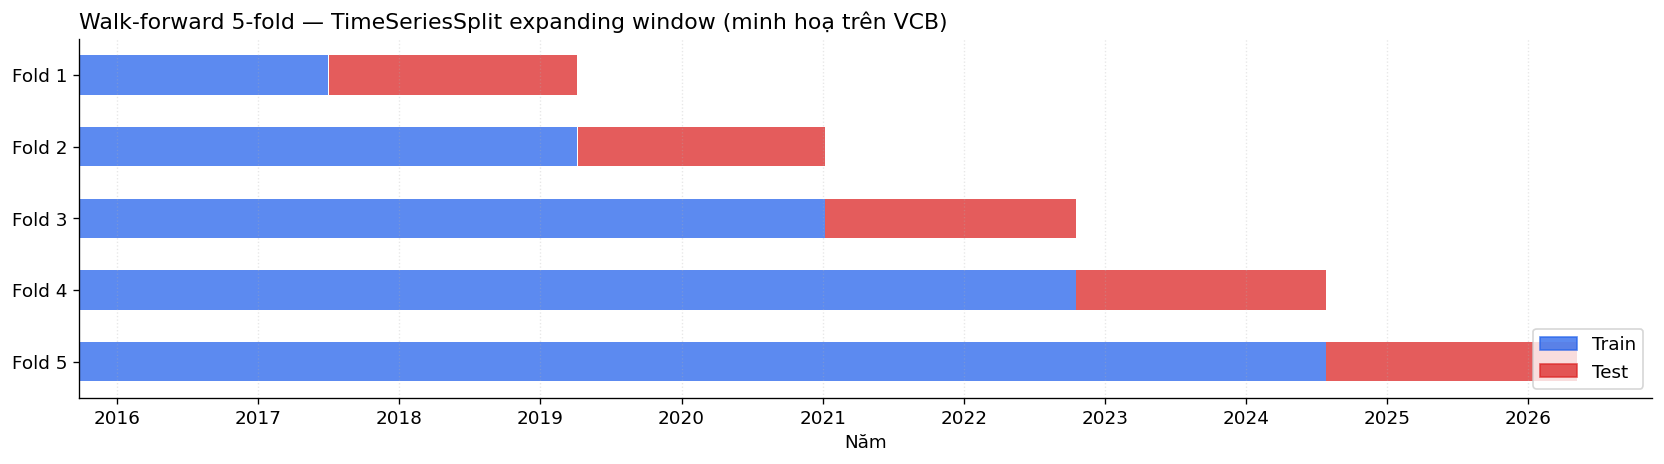


Chi tiết 5 fold:
 Fold   Train từ  Train đến    Test từ   Test đến  Train rows  Test rows
    1 2015-09-25 2017-06-30 2017-07-03 2019-04-05         442        442
    2 2015-09-25 2019-04-05 2019-04-08 2021-01-06         884        442
    3 2015-09-25 2021-01-06 2021-01-07 2022-10-17        1326        442
    4 2015-09-25 2022-10-17 2022-10-18 2024-07-25        1768        442
    5 2015-09-25 2024-07-25 2024-07-26 2026-05-08        2210        442

Khác biệt:
  • Single split: 1 cut date duy nhất → bias nếu thị trường thay đổi regime sau cut.
  • Walk-forward: train mở rộng dần, test ~20% mỗi fold → đo độ ổn định của model qua thời gian.


In [15]:
# ── Single split: 70/30 và 80/20 ──
cut_dates = {}
for entry in split_info:
    t = entry['ticker']
    cut_dates[t] = {
        '70_30': pd.Timestamp(entry['splits']['70_30']['test_start']),
        '80_20': pd.Timestamp(entry['splits']['80_20']['test_start']),
    }

fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=False)

for ax, ticker in zip(axes, TICKERS):
    df   = raw[ticker].sort_values('date')
    c730 = cut_dates[ticker]['70_30']
    c820 = cut_dates[ticker]['80_20']

    ax.axvspan(df['date'].min(), c730, alpha=0.08, color='#2563EB', label='Train 70%')
    ax.axvspan(c730, df['date'].max(), alpha=0.08, color='#DC2626', label='Test 30%')

    ax.plot(df['date'], df['close'], color='#374151', lw=1.0)
    ax.axvline(c730, color='#2563EB', ls='--', lw=1.3, label=f'70/30 cut: {c730.date()}')
    ax.axvline(c820, color='#D97706', ls='--', lw=1.3, label=f'80/20 cut: {c820.date()}')

    ax.set_title(ticker, fontsize=11, fontweight='bold', loc='left')
    ax.set_ylabel('Giá')
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.grid(axis='y', ls=':', alpha=0.3)

axes[-1].set_xlabel('Năm')
fig.suptitle('Single split — Train/Test theo thời gian (không shuffle)', fontsize=13, y=1.005)
plt.tight_layout()
fig.savefig(PLOTS_DIR / '09_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Walk-forward 5-fold (TimeSeriesSplit, expanding window) ──
from sklearn.model_selection import TimeSeriesSplit
from matplotlib.patches import Patch

DEMO = 'VCB'
df_demo = featured[DEMO].sort_values('date').reset_index(drop=True)
tscv = TimeSeriesSplit(n_splits=5)

fold_info = []
fig, ax = plt.subplots(figsize=(14, 4))
for fold, (tr_idx, te_idx) in enumerate(tscv.split(df_demo), 1):
    tr_start = df_demo.iloc[tr_idx[0]]['date']
    tr_end   = df_demo.iloc[tr_idx[-1]]['date']
    te_start = df_demo.iloc[te_idx[0]]['date']
    te_end   = df_demo.iloc[te_idx[-1]]['date']
    fold_info.append({
        'Fold': fold,
        'Train từ': tr_start.date(), 'Train đến': tr_end.date(),
        'Test từ':  te_start.date(), 'Test đến':  te_end.date(),
        'Train rows': len(tr_idx),   'Test rows':  len(te_idx),
    })
    ax.barh(fold, (tr_end - tr_start).days, left=tr_start, height=0.55,
            color='#2563EB', alpha=0.75)
    ax.barh(fold, (te_end - te_start).days, left=te_start, height=0.55,
            color='#DC2626', alpha=0.75)

ax.set_yticks(range(1, 6))
ax.set_yticklabels([f'Fold {i}' for i in range(1, 6)])
ax.invert_yaxis()
ax.set_xlabel('Năm')
ax.set_title(f'Walk-forward 5-fold — TimeSeriesSplit expanding window (minh hoạ trên {DEMO})', loc='left')
ax.legend(handles=[Patch(color='#2563EB', alpha=0.75, label='Train'),
                   Patch(color='#DC2626', alpha=0.75, label='Test')],
          loc='lower right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(axis='x', ls=':', alpha=0.3)
plt.tight_layout()
fig.savefig(PLOTS_DIR / '10_walkforward_folds.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nChi tiết 5 fold:')
print(pd.DataFrame(fold_info).to_string(index=False))
print('\nKhác biệt:')
print('  • Single split: 1 cut date duy nhất → bias nếu thị trường thay đổi regime sau cut.')
print('  • Walk-forward: train mở rộng dần, test ~20% mỗi fold → đo độ ổn định của model qua thời gian.')


---
## 10 — Liên kết EDA → Kỳ vọng mô hình

Các phát hiện EDA định hình kỳ vọng cụ thể cho phần model (Chương 4–5):

- **Giá là chuỗi không dừng** (ADF p > 0.05 cho 4/5 mã, Section 5) → close[t+1] ≈ close[t] + ε. Hệ quả: mọi model "predict close" dùng close[t] làm feature sẽ đạt RMSE thấp giả tạo (R² > 0.95) — không phản ánh kỹ năng dự báo thực sự, chỉ phản ánh "ngày mai gần như hôm nay".

- **Lợi suất là chuỗi dừng** (ADF p ≈ 0 cho cả 5 mã) → có thể model bằng ARIMA/GARCH. Hướng phát triển: chuyển bài toán predict giá → predict lợi suất.

- **Tương quan cao giữa các mã** (ma trận Section 4) → cross-sectional features (return của mã khác, VN-Index) có tiềm năng nâng performance. Phù hợp với hướng "global model" trong Chương 6.

- **VIC có volatility spike gần đây** (Section 8) → walk-forward fold cuối sẽ khó hơn các fold trước. *Xác nhận ở Chương 5: VIC fold 5 RMSE = 3.34 vs 0.5–0.9 ở fold 1–4 — khớp với dự đoán.*

- **Random walk → Directional Accuracy ≈ 50%** → Linear Regression dự đoán đúng hướng (tăng/giảm) gần như random. Mong đợi cùng kết quả với baseline naive; LSTM/Prophet với khả năng học non-linear mới có cơ hội vượt 50%. *Xác nhận ở Chương 5: LR DA = 48.6–53.5%.*

- **Indicators (MA, RSI, MACD, BB) lag close** → dùng làm feature cho t+1 không leak nhưng không cung cấp nhiều thông tin hơn close[t] khi model đã có close. Có giá trị thực sự khi predict horizon ≥ 2 ngày.


---
## 11 — Bảng tóm tắt cho Chương 3


In [16]:
summary_rows = []
for ticker in TICKERS:
    df  = raw[ticker].sort_values('date').dropna(subset=['close'])
    ret = df['close'].pct_change().dropna() * 100
    adf_price  = adfuller(df['close'], autolag='AIC')
    adf_return = adfuller(ret, autolag='AIC')

    si = next(e for e in split_info if e['ticker'] == ticker)
    summary_rows.append({
        'Mã':               ticker,
        'Số phiên':         len(df),
        'Từ':               str(df['date'].min().date()),
        'Đến':              str(df['date'].max().date()),
        'Giá TB':           round(df['close'].mean(), 1),
        'Std lợi suất (%)': round(ret.std(), 3),
        'ADF giá (p)':      round(adf_price[1], 4),
        'ADF lợi suất (p)': round(adf_return[1], 6),
        'Train 70/30':      si['splits']['70_30']['train_rows'],
        'Test 70/30':       si['splits']['70_30']['test_rows'],
        'Train 80/20':      si['splits']['80_20']['train_rows'],
        'Test 80/20':       si['splits']['80_20']['test_rows'],
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

out_csv = ROOT / 'results' / 'eda' / 'chapter3_summary.csv'
summary_df.to_csv(out_csv, index=False, encoding='utf-8-sig')
print(f'\nĐã lưu → {out_csv.relative_to(ROOT)}')

 Mã  Số phiên         Từ        Đến  Giá TB  Std lợi suất (%)  ADF giá (p)  ADF lợi suất (p)  Train 70/30  Test 70/30  Train 80/20  Test 80/20
VCB      2702 2015-07-16 2026-05-08    38.3             1.755       0.7269               0.0         1856         796         2121         531
FPT      2702 2015-07-16 2026-05-08    42.6             1.657       0.8100               0.0         1856         796         2121         531
HPG      2702 2015-07-16 2026-05-08    14.8             2.069       0.7475               0.0         1856         796         2121         531
VIC      2702 2015-07-16 2026-05-08    39.2             2.069       1.0000               0.0         1856         796         2121         531
VNM      2702 2015-07-16 2026-05-08    66.0             1.532       0.0454               0.0         1856         796         2121         531

Đã lưu → results/eda/chapter3_summary.csv


In [17]:
print('Các biểu đồ đã lưu tại results/eda/plots/:')
for p in sorted(PLOTS_DIR.iterdir()):
    print(f'  {p.name}')

Các biểu đồ đã lưu tại results/eda/plots/:
  01_close_price_all.png
  02_normalized_price.png
  03_returns_distribution.png
  04_rolling_volatility.png
  05_correlation_matrix.png
  06_decomposition_FPT.png
  06_decomposition_HPG.png
  06_decomposition_VCB.png
  06_decomposition_VIC.png
  06_decomposition_VNM.png
  07_technical_indicators_VCB.png
  08_train_test_split.png
  08_vic_volatility.png
  09_train_test_split.png
  10_walkforward_folds.png


---
## Ghi chú viết Chương 3

### 3.1 Nguồn dữ liệu
- Nguồn chính: **vnstock** (VCI) — dữ liệu OHLCV sàn HOSE/HNX
- Fallback: **yfinance** (suffix `.VN`) — dùng khi VCI block IP ngoài VN
- Khoảng thời gian: ~10 năm (2015-07 → 2026-05), ~2 700 phiên mỗi mã

### 3.2 Làm sạch dữ liệu (silver layer — `src/clean.py`)
- Loại bỏ duplicate ngày, sắp xếp chronological
- Xóa hàng có `close = NaN` (lỗi cấu trúc — không fillable)
- Forward-fill ≤3 phiên liên tiếp cho OHL + volume (bù khoảng trống cuối tuần dài)

### 3.3 Feature Engineering (gold layer — `src/features.py`)
| Indicator | Tham số | Ý nghĩa |
|---|---|---|
| MA | 5, 20, 50 ngày | Xu hướng ngắn/trung/dài hạn |
| RSI | 14 ngày | Momentum, vùng mua/bán quá mức (30/70) |
| MACD | 12/26/9 | Sự hội tụ/phân kỳ trung bình động |
| Bollinger Bands | 20 ngày, ±2σ | Biên biến động |

Drop 50 dòng đầu (warm-up) để mọi indicator đều populated. Kiến trúc tách bronze/silver/gold giúp debug "lỗi data quality vs lỗi feature engineering" ngay tại lớp.

### 3.4 Tính dừng
- Chuỗi giá **không dừng** (ADF p > 0.05 cho 4/5 mã; VNM ngoại lệ p = 0.045) — đặc tính random walk
- Chuỗi lợi suất **dừng** (ADF p ≈ 0 cho cả 5 mã) — phù hợp ARIMA/GARCH

### 3.5 Outlier — Trường hợp VIC (Section 8)
- VIC có volatility spike rõ rệt từ 2024 → walk-forward fold cuối khó hơn các fold trước
- Top phiên |return| lớn nhất tập trung ở giai đoạn này → giải thích cho RMSE 3.34 ở fold 5 (Chương 5)

### 3.6 Chia tập dữ liệu (Section 9)
- Chia **theo thời gian** (không shuffle) để tránh data leakage
- **Single split**: 70/30 (test từ 2023-02) và 80/20 (test từ 2024-03)
- **Walk-forward 5-fold**: TimeSeriesSplit expanding window — dùng cho benchmark stability ở Chương 5

### 3.7 Liên kết EDA → mô hình (Section 10)
- Random walk + DA ≈ 50% → kỳ vọng Linear Regression có RMSE thấp nhưng directional skill = random
- Hướng phát triển: predict lợi suất, global model (cross-sectional), probabilistic forecast với prediction intervals
